# Load the libraries

In [238]:
# === System & Utility Imports === #
import os
import sys
import subprocess
import importlib
import gc  # Garbage collector
import math
import re

# === Data Handling === #
import numpy as np
import pandas as pd
import polars as pl
import h5py

# === Visualization === #
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# === Scikit-Learn === #
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
)
from sklearn.metrics import r2_score
from sklearn.utils import resample
from sklearn.neighbors import KernelDensity

# === PyTorch === #
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

# === Misc === #
from enum import Enum
from numpy.lib import recfunctions as rfn

# === Install required packages if missing === #
result = subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "h5py", "pandas", "numpy", "torch", "torch_optimizer",
     "polars", "matplotlib", "scikit-learn", "torchinfo", "seaborn"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

if result.returncode != 0:
    print("Package installation failed.")

def read_h5_data(file_name):
    with h5py.File(file_name, 'r') as file:
        particles = file['INPUTS']['PARTICLES'][:, :42]  # First 43 columns/features
        metadata = file['METADATA']['EVENT_DATA'][:]

        signal_inputs = rfn.structured_to_unstructured(particles)

        particles_keys = list(file['INPUTS']['PARTICLES'].dtype.names)[:42]
        input_keys_dict = {key: idx for idx, key in enumerate(particles_keys)}

    return signal_inputs, metadata, input_keys_dict

def load_multiple_h5(files):
    all_signals = []
    all_metadata = []
    input_keys_dict = None

    for f in files:
        signals, metadata, keys_dict = read_h5_data(f)
        all_signals.append(signals)
        all_metadata.append(metadata)
        if input_keys_dict is None:
            input_keys_dict = keys_dict

    combined_signals = np.vstack(all_signals)
    combined_metadata = np.vstack(all_metadata)

    return combined_signals, combined_metadata, input_keys_dict

def flat_inputs(input_array, n_particles, feature_indices=None):
    if feature_indices is None:
        feature_indices = list(range(input_array.shape[2]))  # Use all features if none specified

    # Select specific particles and features
    output_array = input_array[:, :n_particles, feature_indices]
    
    # Transpose to (samples, features, particles)
    output_array = output_array.transpose(0, 2, 1)
    
    # Flatten to (samples, n_particles * n_features_selected)
    return output_array.reshape(-1, n_particles * len(feature_indices))
    
# Class holding enums for the possible indices of the metadata
class MetadataIndex(Enum):
    # EVENT_NUMBER = 0 No need to assing this 
    OMEGA = 1
    MZ_RECO = 2
    MZ_TRUTH = 3
    MMC_MZ = 4
    OPENING_ANGLE = 5
    LEP_MET_ANGLE_SIGNED = 6
    IS_MET_INSIDE = 7
    IS_EVENT_TPG_HADEL = 8
    TAU_GOOD_ID = 9
    TAU_GOOD_N_TRACKS = 10
    TAU_NN_DECAY = 11
    THREE_BODY_TRAN_MASS = 12
    M3_STAR = 13

# Read the Inputs

In [239]:
files = [
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20a_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20d_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_Sherpa2211_700360_mc20e_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20a_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20d_fullsim.h5',
    '../../../H5Dumper/VBF_Ztautau_PoPy_600939_mc20e_fullsim.h5',
]

# Reading the input files and deleting any with invalid Missing-Mass-Calculator values
signal_inputs, metadata_inputs, input_keys_dict = load_multiple_h5(files)
signal_inputs = np.delete(signal_inputs, np.where(metadata_inputs[:, MetadataIndex.MMC_MZ.value] == 0), axis=0)
metadata_inputs = np.delete(metadata_inputs, np.where(metadata_inputs[:, MetadataIndex.MMC_MZ.value] == 0), axis=0)

print(signal_inputs.shape)
print(metadata_inputs.shape)

# Print the available columns to be read from the signal and metadata
print(f'Particle input Cols: {input_keys_dict}')
with h5py.File(files[0], 'r') as file:
    columns = [name.decode() for name in file['METADATA']['EVENT_DATA'].attrs['columns']]
    print(f'Metadata Cols: {columns}')

(194421, 35, 7)
(194421, 14)
Particle input Cols: {'e': 0, 'eta': 1, 'phi': 2, 'pt': 3, 'btag': 4, 'charge': 5, 'type': 6}
Metadata Cols: ['ljet_GN2_quantile_NOSYS', 'Lep_charge', 'tau_good_charge_NOSYS', 'met_tight_met_NOSYS', 'met_tight_phi_NOSYS', 'eventNumber', 'omega_NOSYS', 'MZ_NOSYS', 'MATCHED_tau_tau_MZ', 'mmc_mlm_mass_NOSYS', 'opening_angle_NOSYS', 'lep_MET_phi_signed_NOSYS', 'isMissingETInside_NOSYS', 'event_topology_NOSYS', 'tau_good_ID_quantile_NOSYS', 'tau_good_n_tracks_NOSYS', 'tau_NNDecayMode', 'ThreeBodyTranMass_NOSYS', 'M3Star_NOSYS']


# Data Exploration

In [240]:
import numpy as np
import matplotlib.pyplot as plt

def compare_distribution_tails(data, left_tail_ind, right_tail_ind, x_range=None, variable_name='', n_bins=40, metadata=False):
    plt.figure(figsize=(10, 6), dpi=100)
    
    # Extract the variable column if given
    if variable_name != '' and not metadata:
        feature_index  = input_keys_dict[variable_name[:-1]]  # everything except last char
        particle_index = int(variable_name[-1])
        array = data[:, particle_index, feature_index]
    else:
        array = data
    
    # Identify the three regions
    left_tail  = array[left_tail_ind]
    right_tail = array[right_tail_ind]
    
    # Peak = all indices not in left or right
    all_idx = np.arange(len(array))
    peak_ind = np.setdiff1d(all_idx, np.concatenate([left_tail_ind, right_tail_ind]))
    peak = array[peak_ind]
    
    # Determine x range if not provided
    if x_range is None:
        x_range_max = np.nanmax(array)
        x_range_min = np.nanmin(array)
        x_range = [x_range_min, x_range_max]
    
    # Plot histograms
    plt.hist(left_tail,  bins=n_bins, range=x_range, histtype='step', label='Left tail',  density=True, color='blue')
    plt.hist(peak,       bins=n_bins, range=x_range, histtype='step', label='Peak',       density=True, color='green')
    plt.hist(right_tail, bins=n_bins, range=x_range, histtype='step', label='Right tail', density=True, color='red')
    
    plt.xlabel(variable_name)
    plt.ylabel('Density')
    plt.title(f'Distribution: {variable_name}')
    plt.legend()
    plt.show()



def obtain_max_n_particles_in_dataset(dataset):

    max_n_particles_per_event = []
    max_n_particles = 0
    for event in range(0,dataset.shape[0]):
        #if (event % 100000 == 0):
            #print('Reading event %d' % event)
            #print('Max number of particles so far = %d' % max_n_particles)
        for particle in range(0,43):
            if np.isnan(dataset[event][particle][0]):
                if max_n_particles < particle:
                    max_n_particles = particle+1
                max_n_particles_per_event.append(particle)
                break

    return max_n_particles, max_n_particles_per_event

In [241]:
max_n_particles_signal, n_particles_signal_dist = obtain_max_n_particles_in_dataset(signal_inputs)
print('max_particles_signal = ', max_n_particles_signal)

max_particles_signal =  27


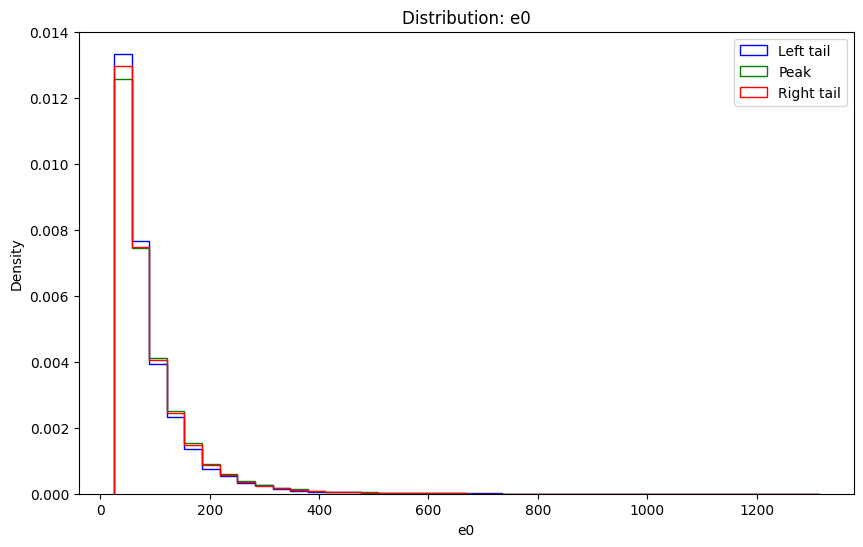

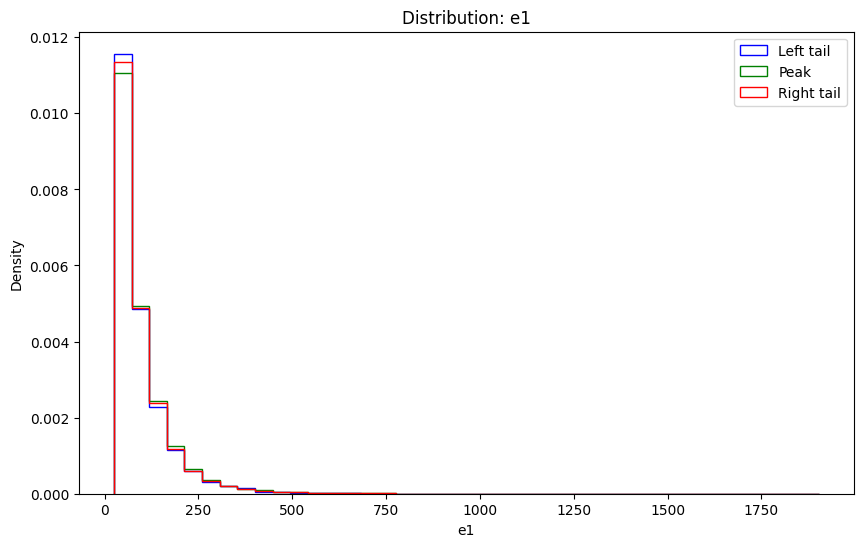

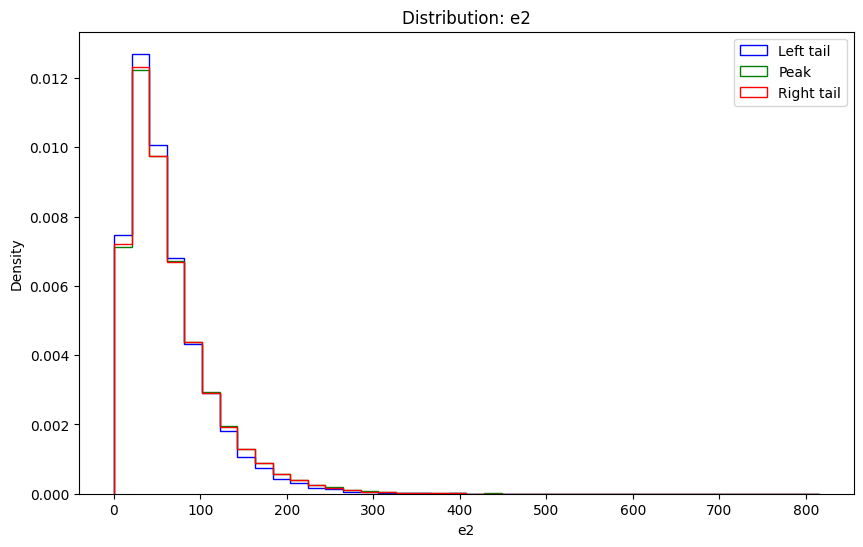

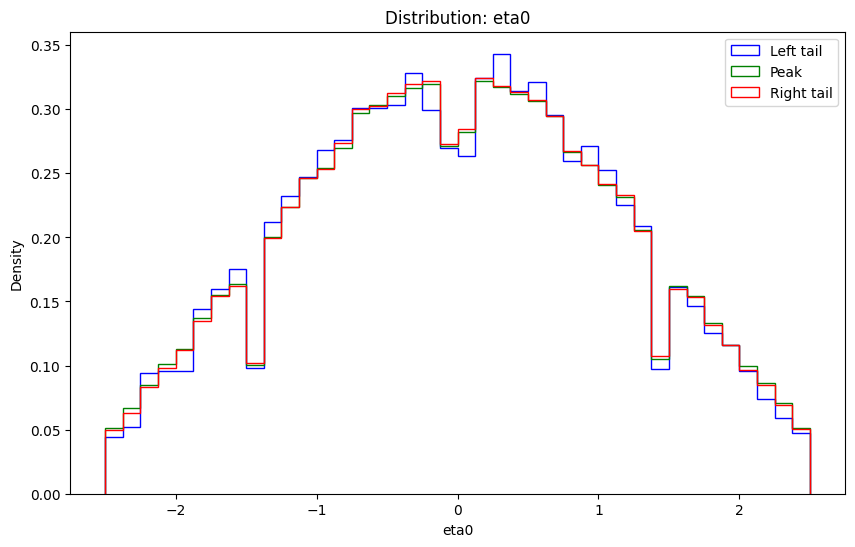

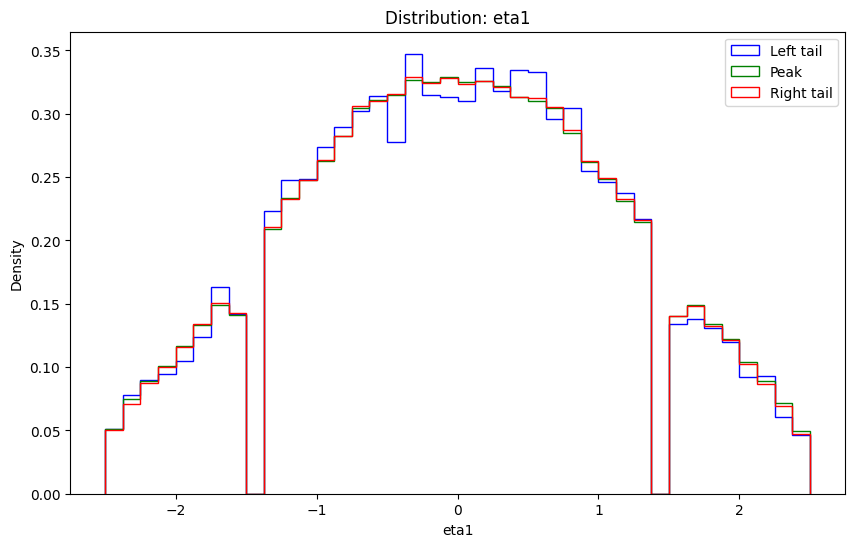

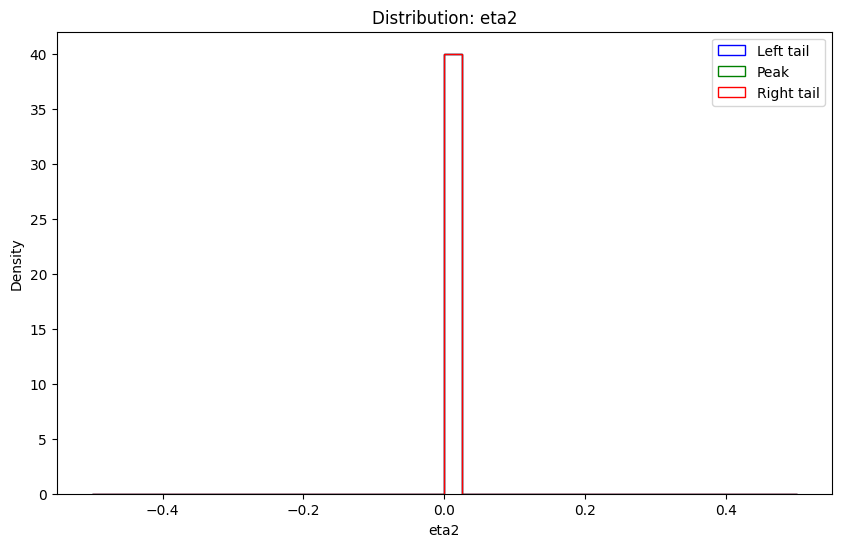

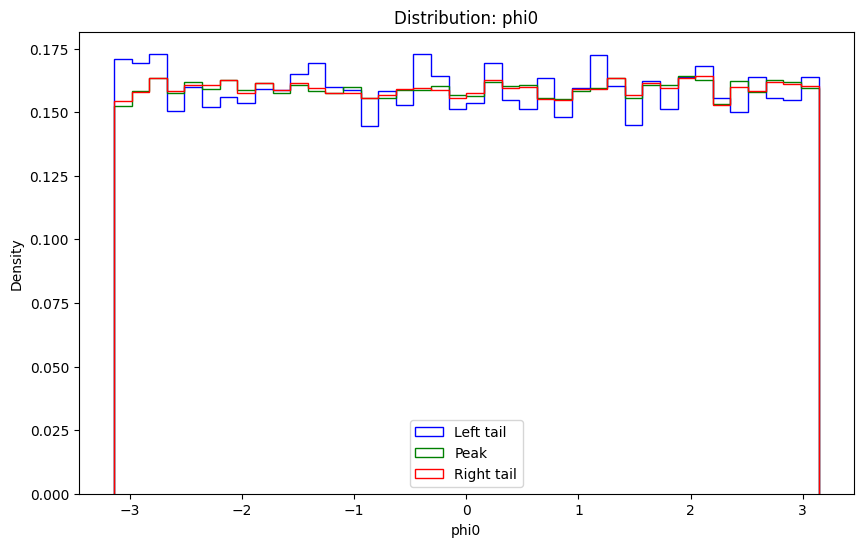

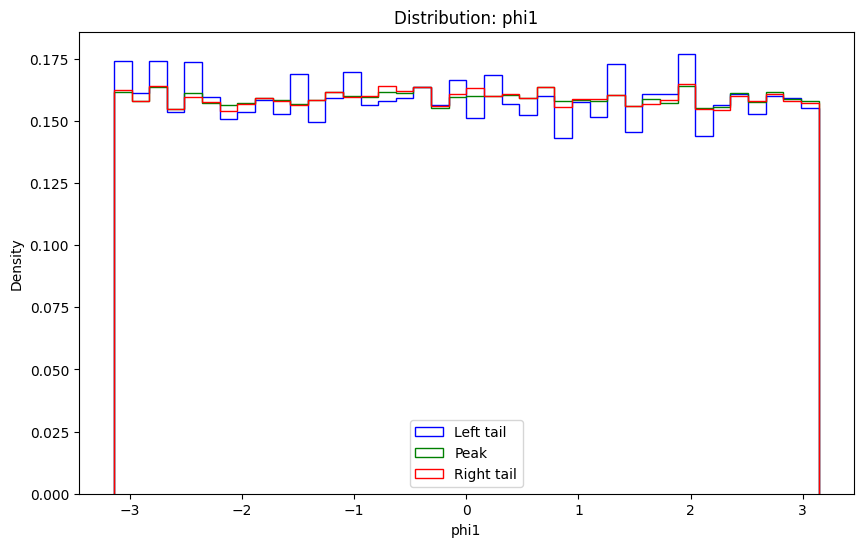

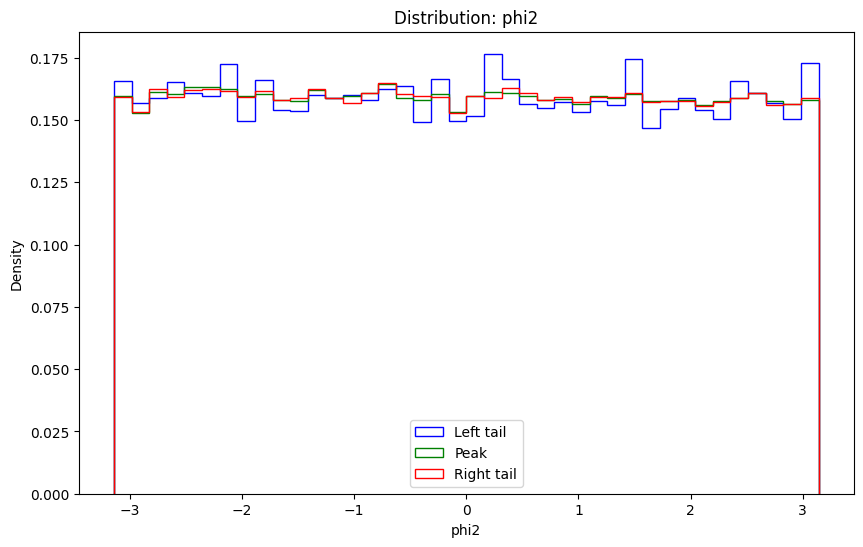

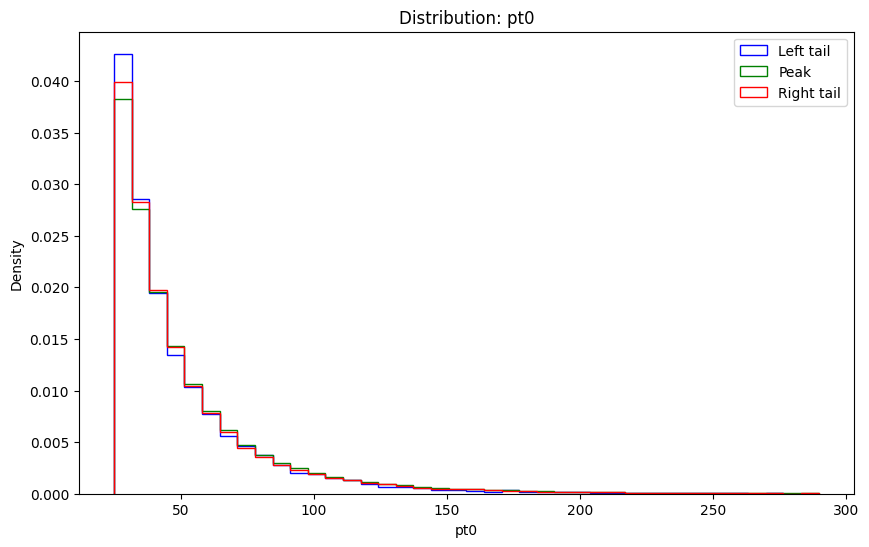

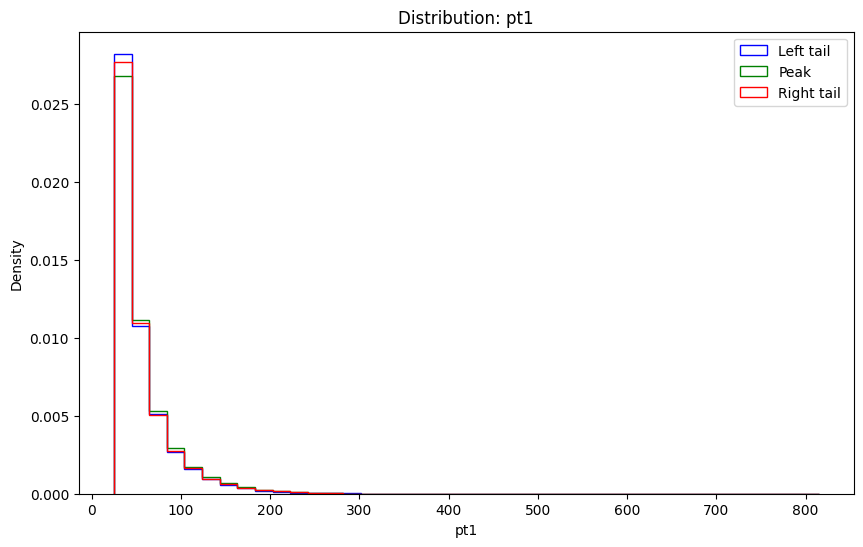

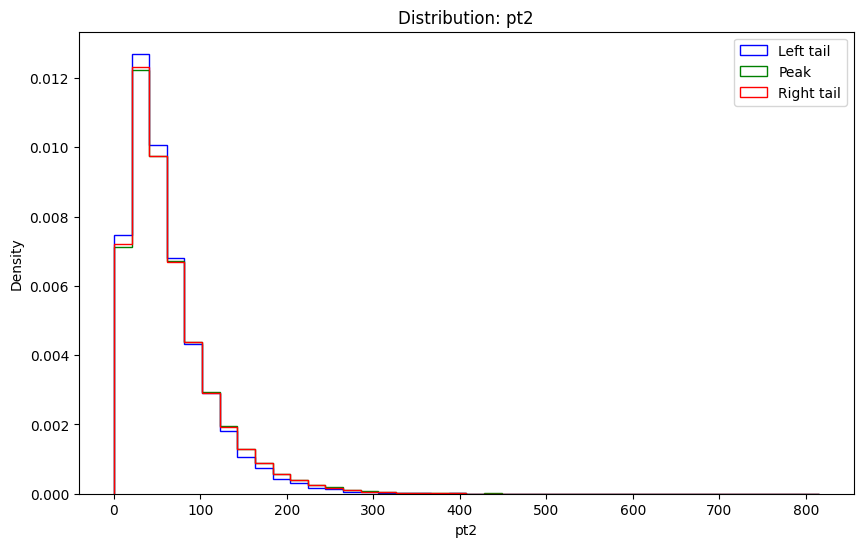

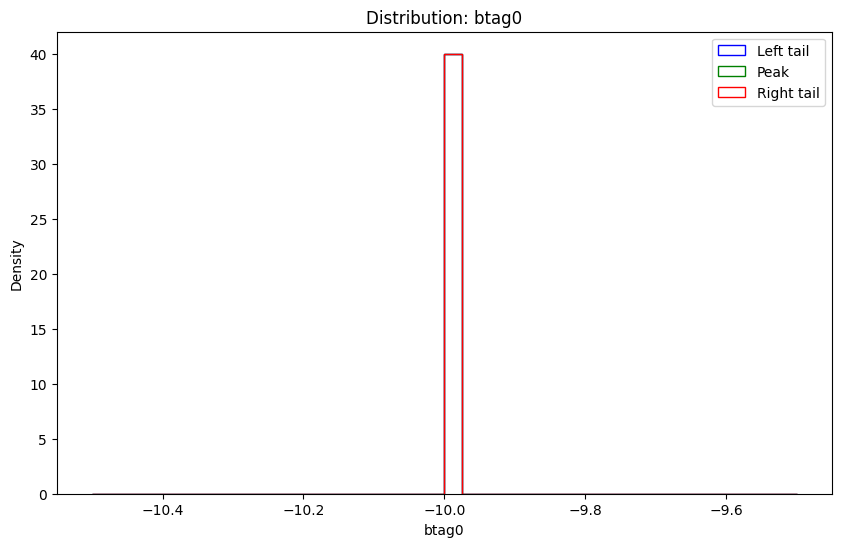

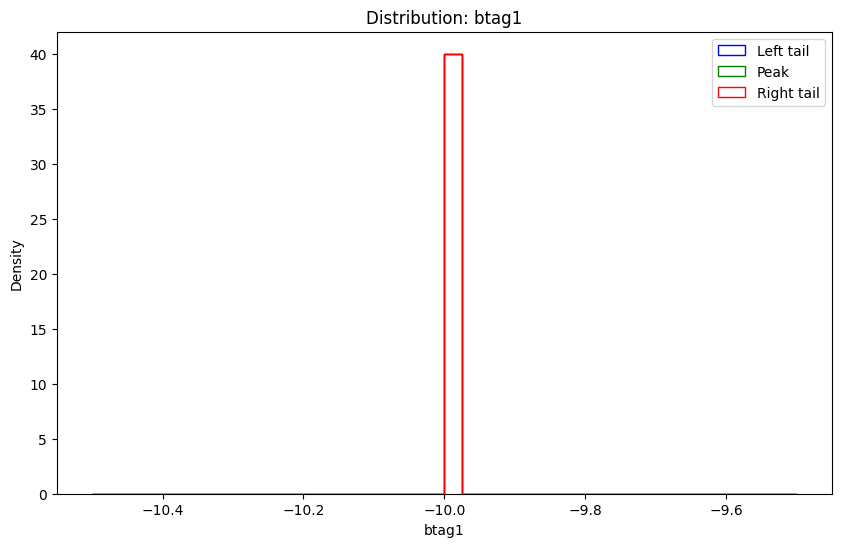

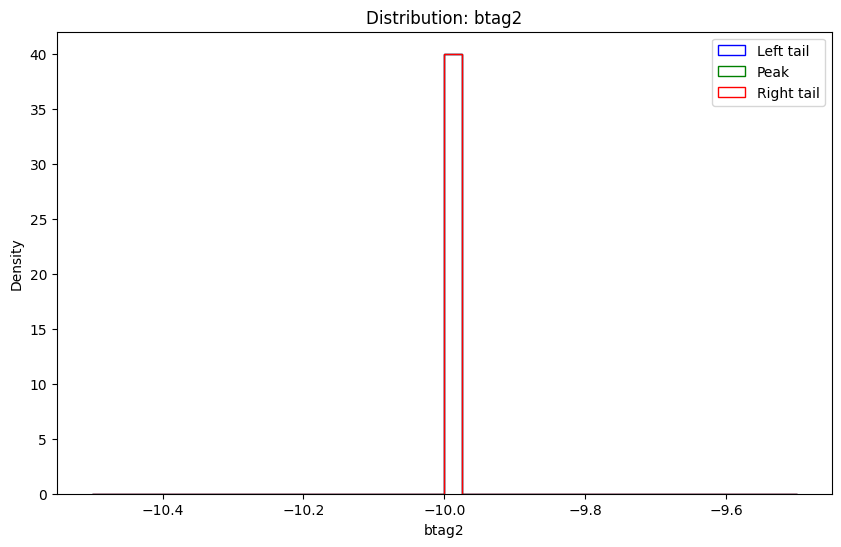

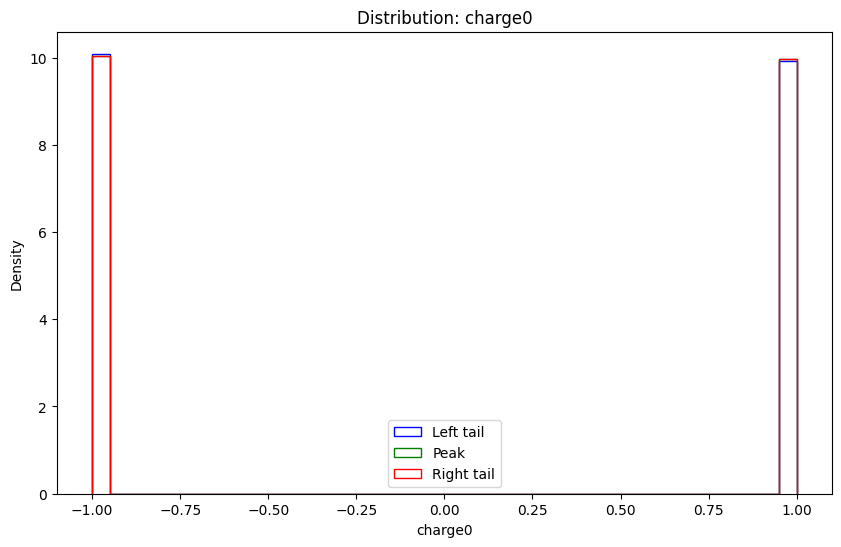

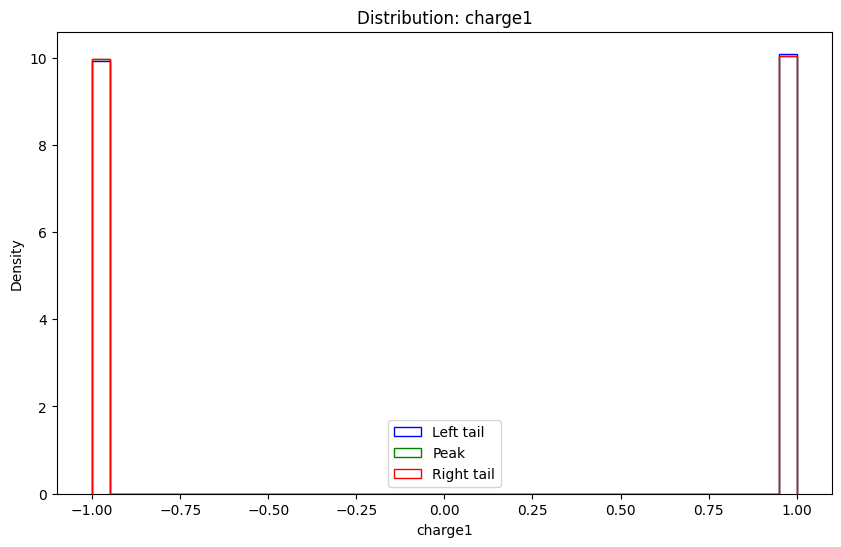

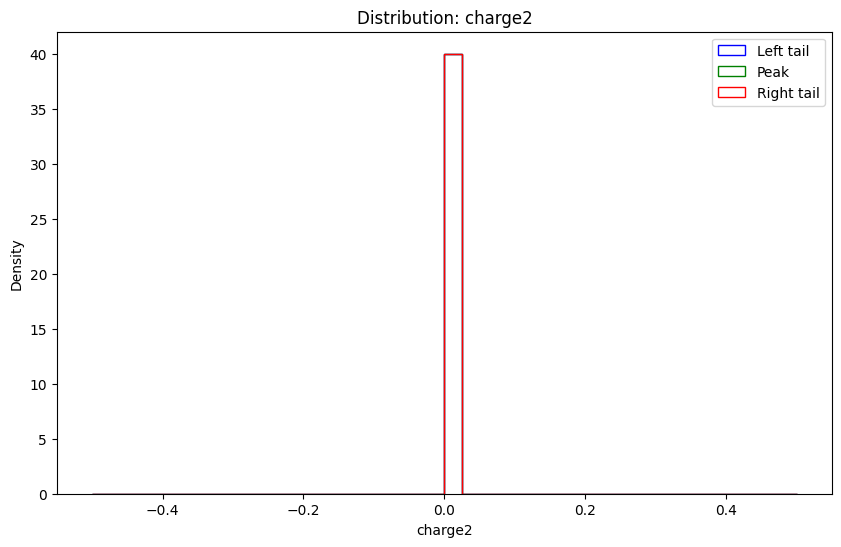

In [242]:
left_tail_ind = metadata_inputs[:, MetadataIndex.MZ_TRUTH.value] < 91.8 - 5
right_tail_ind = metadata_inputs[:, MetadataIndex.MZ_TRUTH.value] < 91.8 + 5

for i in ['e','eta','phi','pt','btag','charge']:
    for j in ['0','1','2']:
        compare_distribution_tails(signal_inputs,left_tail_ind,right_tail_ind,variable_name=i+j)

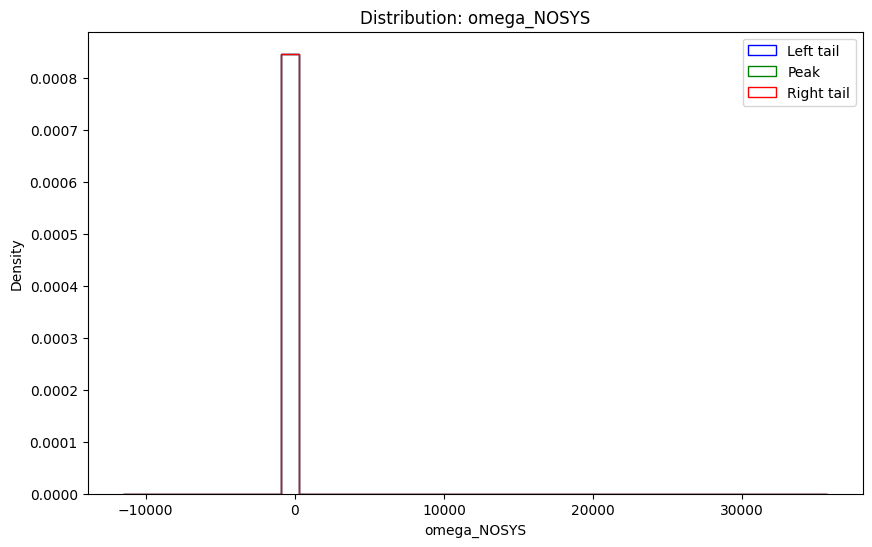

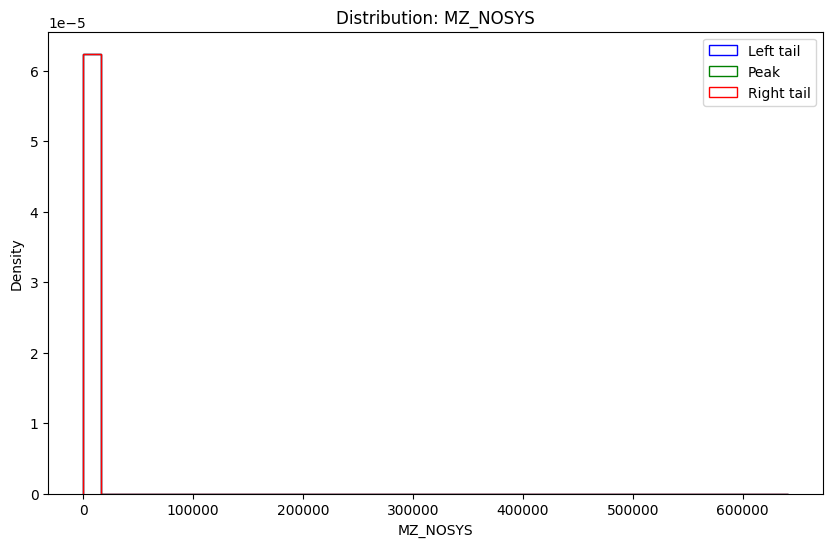

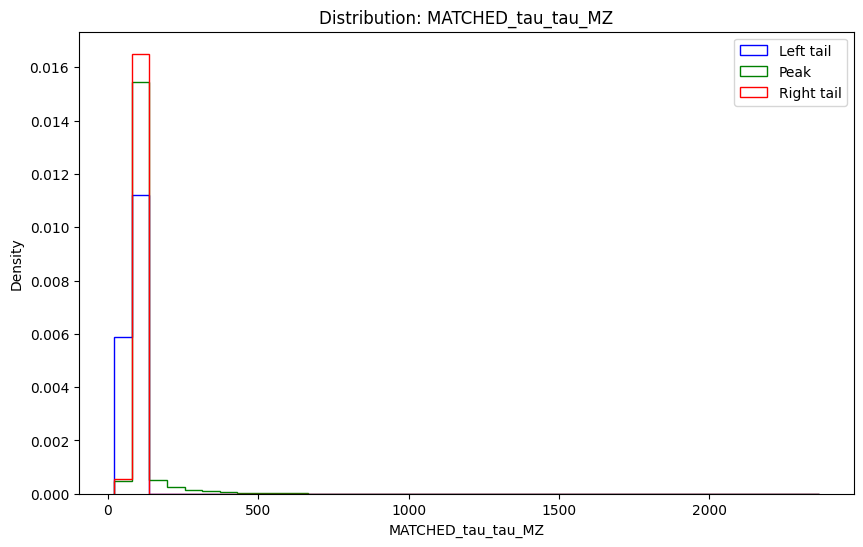

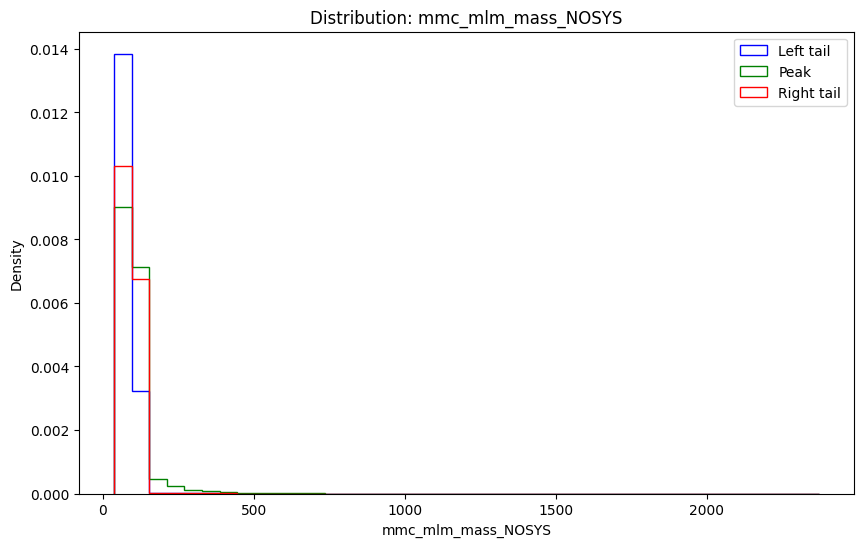

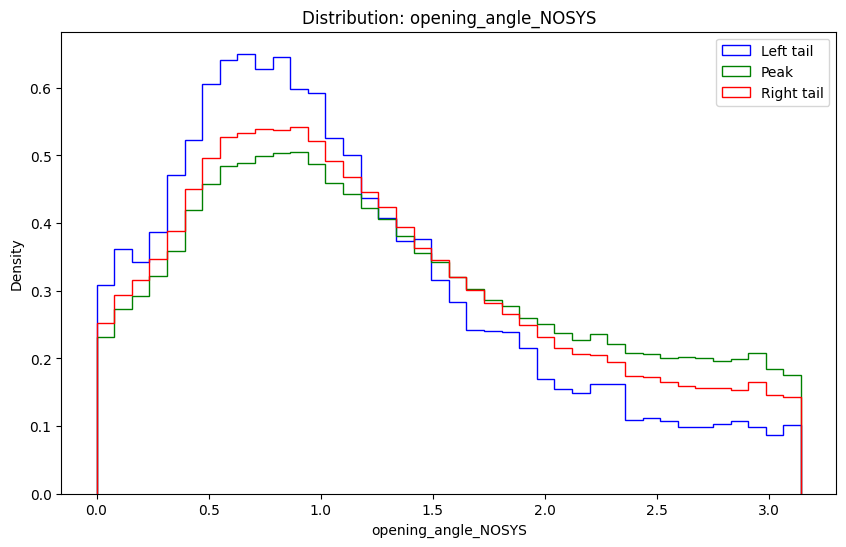

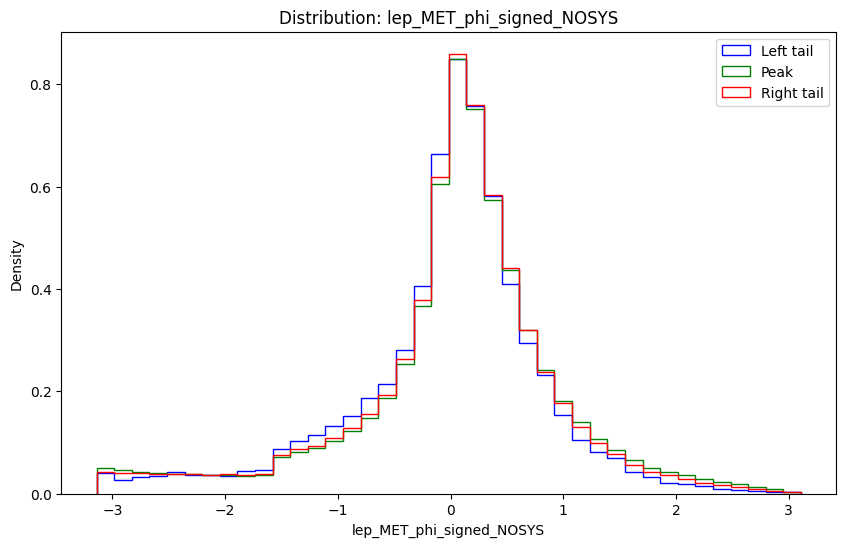

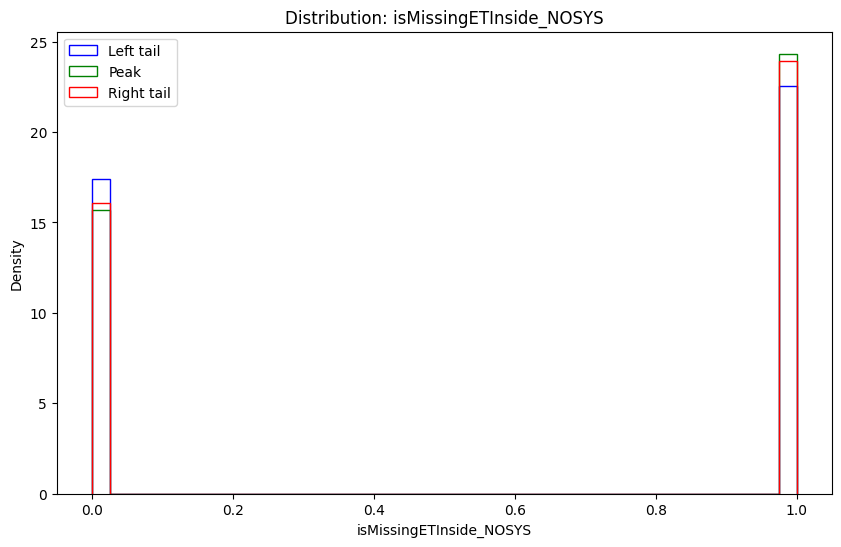

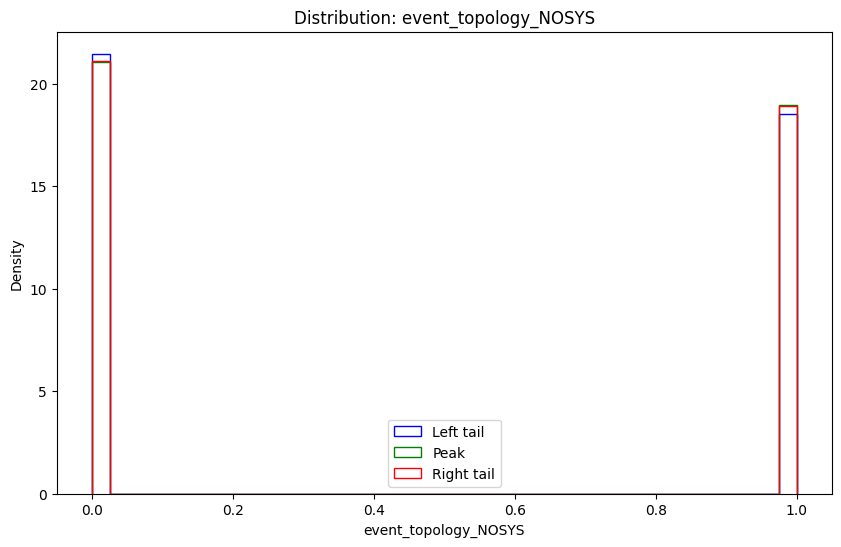

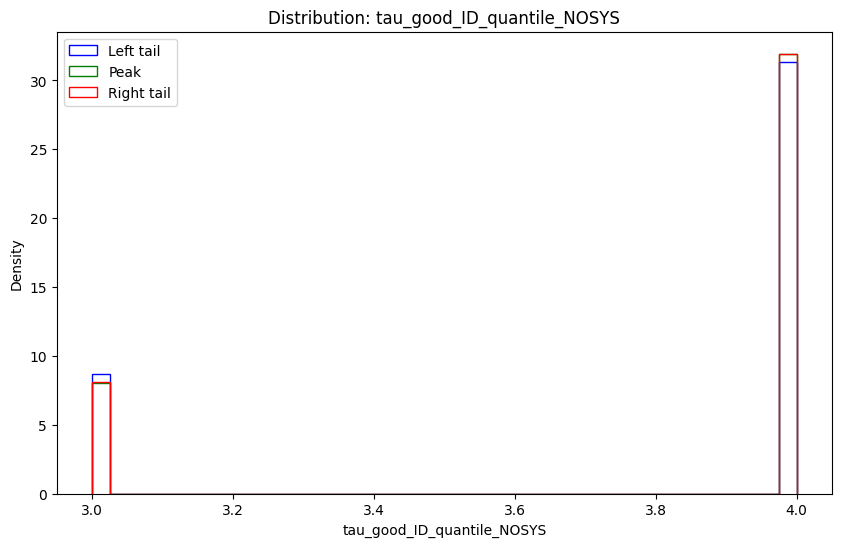

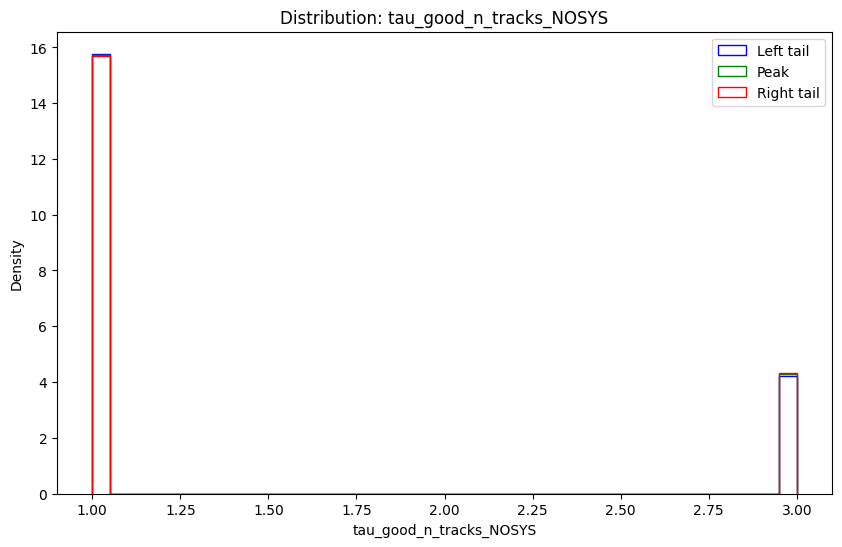

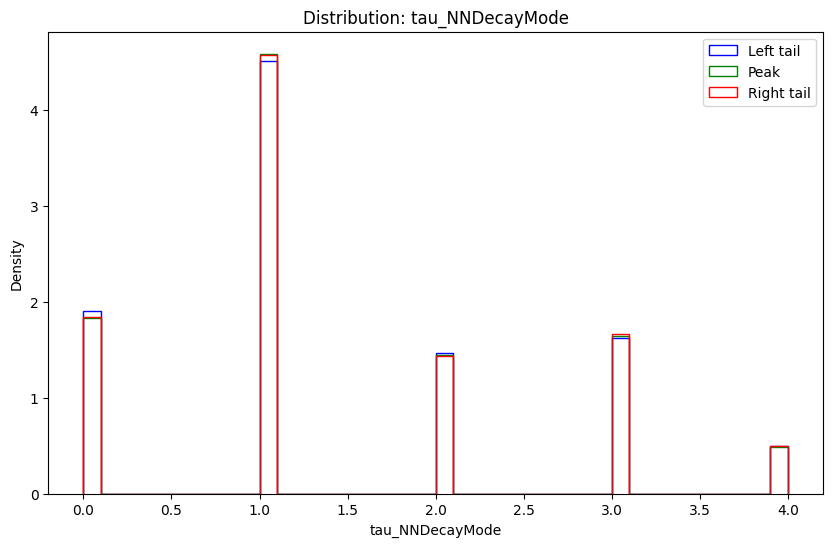

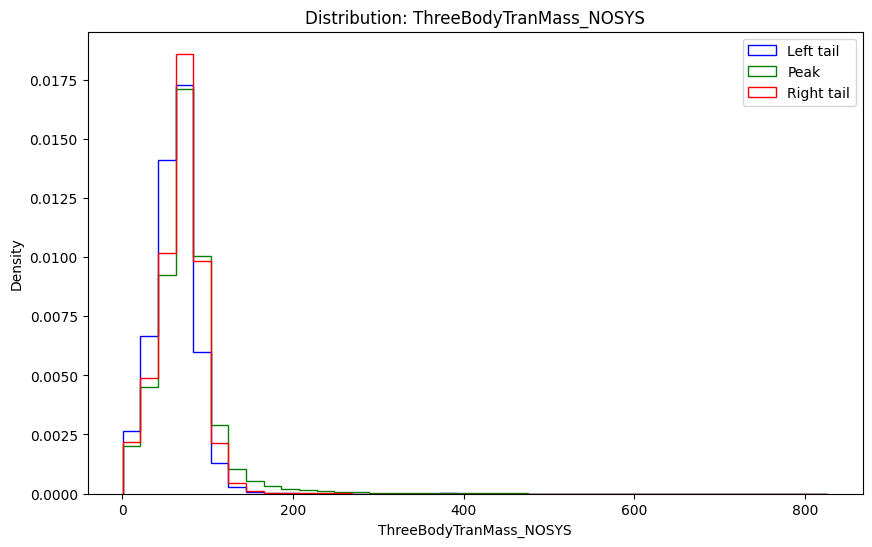

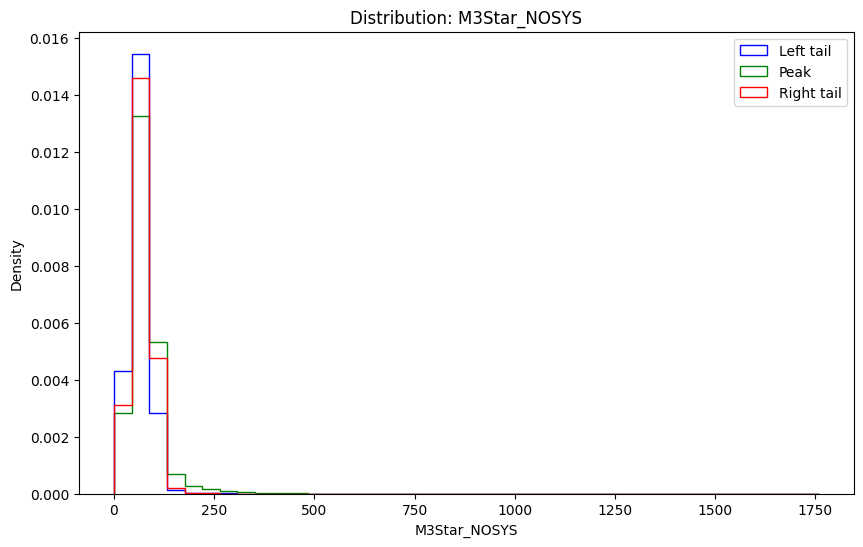

In [243]:
# Skipping the first index containing event details
for i in range(1, len(metadata_inputs[0])):
    compare_distribution_tails(metadata_inputs[:, i],left_tail_ind,right_tail_ind,variable_name=columns[i+ 5], metadata=True)

# Select data to be input in the model

In [244]:
N_PARTICLES = 5 
FEATURES = [0, 1, 2, 3, 4, 5, 6]  # Indices of which particle inputs to use

input_data = flat_inputs(signal_inputs, N_PARTICLES, FEATURES)
target = metadata_inputs[:, MetadataIndex.MZ_TRUTH.value]

# In this model we will add the same extra feature to all the tokens
extra_info_data = np.array( [metadata_inputs[:, MetadataIndex.MMC_MZ.value], ] ).T

In [245]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # and choosing device for training
print(f"Using {device} device")

Using cuda device


In [246]:
indices = np.arange(len(input_data)) # Get original indices

# First split: Train and Temp
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    input_data, target, indices, test_size=0.2, random_state=0, shuffle=True
)

# Second split: Val and Test from Temp
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.5, shuffle=True, random_state=0
)

extra_train = extra_info_data[idx_train, :]
extra_val = extra_info_data[idx_val, :]
extra_test = extra_info_data[idx_test, :]

print(extra_train)
print(X_val)

[[108.34968 ]
 [ 91.58671 ]
 [ 67.04374 ]
 ...
 [ 83.999596]
 [103.141304]
 [ 88.649796]]
[[ 42.93591  102.07036   19.99656  ...   4.         1.         1.      ]
 [281.0374    47.22395   44.896816 ...   4.         1.         1.      ]
 [ 59.027042  57.530094  88.80242  ...   4.         1.         1.      ]
 ...
 [ 37.481247  51.46647   65.37079  ...   4.         1.         1.      ]
 [ 35.88756   49.644825  40.21647  ...   4.         1.         1.      ]
 [119.33074   40.747234 191.62521  ...   4.         1.         1.      ]]


# Scaler Classes

In [247]:
class LogMinMaxScaler(BaseEstimator, TransformerMixin):
    def __init__(self, add_mask=False):
        self.scaler = MinMaxScaler()
        self.add_mask = add_mask

    def fit(self, X, y=None):
        X_log = np.log1p(X)
        # Fit scaler only on non-NaN values (mask out NaNs)
        self.mask_ = np.isnan(X_log)
        # Use only non-NaN values for fitting scaler (flattened)
        self.scaler.fit(X_log[~self.mask_].reshape(-1, 1))
        return self

    def transform(self, X):
        X_log = np.log1p(X)
        mask = np.isnan(X_log)

        # Prepare array to store scaled results, initially all NaN
        X_scaled = np.full_like(X_log, np.nan, dtype=float)

        # Scale only non-NaN values
        non_nan_idx = ~mask
        # MinMaxScaler expects 2D array for transform
        scaled_values = self.scaler.transform(X_log[non_nan_idx].reshape(-1, 1)).flatten()
        X_scaled[non_nan_idx] = scaled_values

        if self.add_mask:
            return np.hstack([mask, X_scaled])
        return X_scaled

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return None
        scaled_names = [f"{name}" for name in input_features]
        if self.add_mask:
            mask_names = [f"{name}_nan_mask" for name in input_features]
            return mask_names + scaled_names
        return scaled_names
        
class PhiTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        sin_phi = np.sin(X)
        cos_phi = np.cos(X)
        return np.hstack([sin_phi, cos_phi])

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f"x{i}" for i in range(self.n_features_in_)]

        # Extract the raw feature name without namespace (e.g., 'phi__x14' -> 'x14')
        def clean_name(name):
            if '__' in name:
                prefix, var = name.split('__', 1)
                return f"{prefix}{var}"  # e.g., phi__x14 -> phix14
            return name  # fallback

        out = []
        for feat in input_features:
            base = clean_name(feat)
            out.append(f"sin({base})")
            out.append(f"cos({base})")
        return np.array(out)
        
class NoOpScaler(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self  
        
    def transform(self, X):
        return np.asarray(X)  # Return input unchanged

    def inverse_transform(self, X):
        return np.asarray(X)  # Also return unchanged

In [248]:
# do add_mask = True if some variables contain nans
scaler = ColumnTransformer(
    [('E', LogMinMaxScaler(), list(range(0, 5))),
    ('eta', StandardScaler(), list(range(5, 10))),
    ('phi', PhiTransformer(), list(range(10, 15))),
    ('pt', LogMinMaxScaler(), list(range(15, 20))), 
    ('btag', MinMaxScaler(), list(range(20, 25))), 
    ('charge', NoOpScaler(), list(range(25, 30))), 
    ('type', NoOpScaler(), list(range(30, 35)))  ],
)

extra_scaler = ColumnTransformer(
    [('MZ_mmc', StandardScaler(), [0])],
)

target_scaler = StandardScaler()

In [249]:
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

Extra_train = extra_scaler.fit_transform(extra_train)
Extra_val   = extra_scaler.transform(extra_val)
Extra_test  = extra_scaler.transform(extra_test)

y_train = target_scaler.fit_transform(y_train.reshape(-1, 1)).T[0]
y_val   = target_scaler.transform(y_val.reshape(-1, 1)).T[0]
y_test  = target_scaler.transform(y_test.reshape(-1, 1)).T[0]

print(X_train.shape)
print(Extra_train.shape)
print(y_train.shape)

(155536, 40)
(155536, 1)
(155536,)


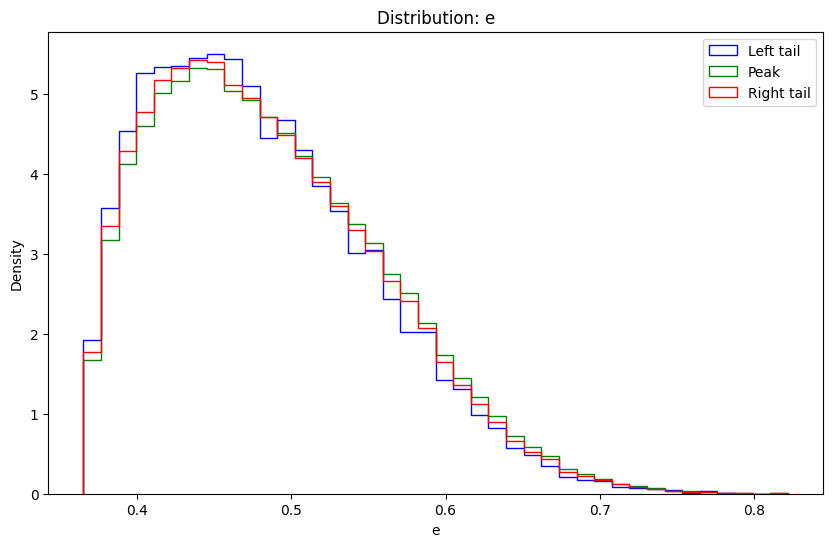

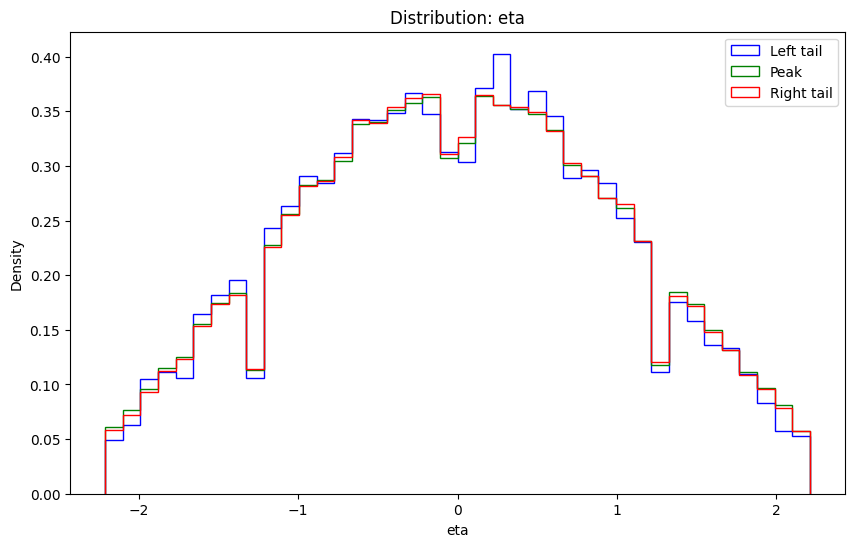

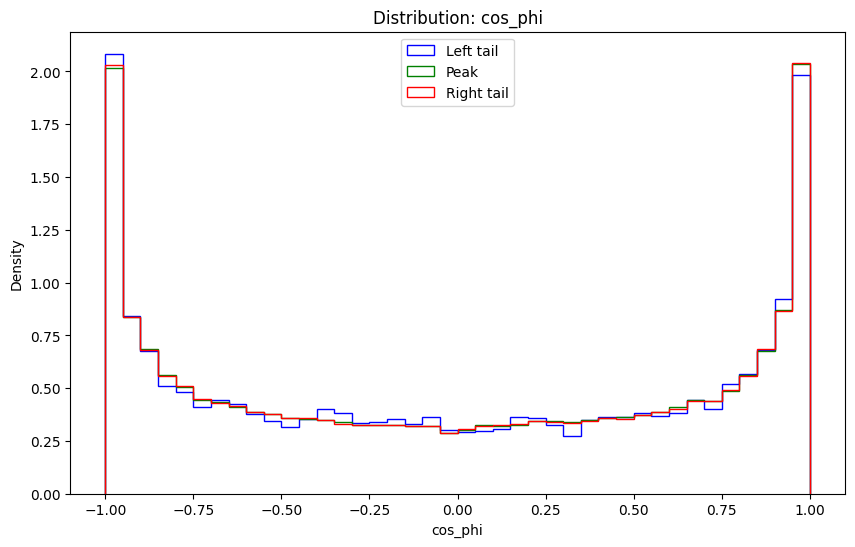

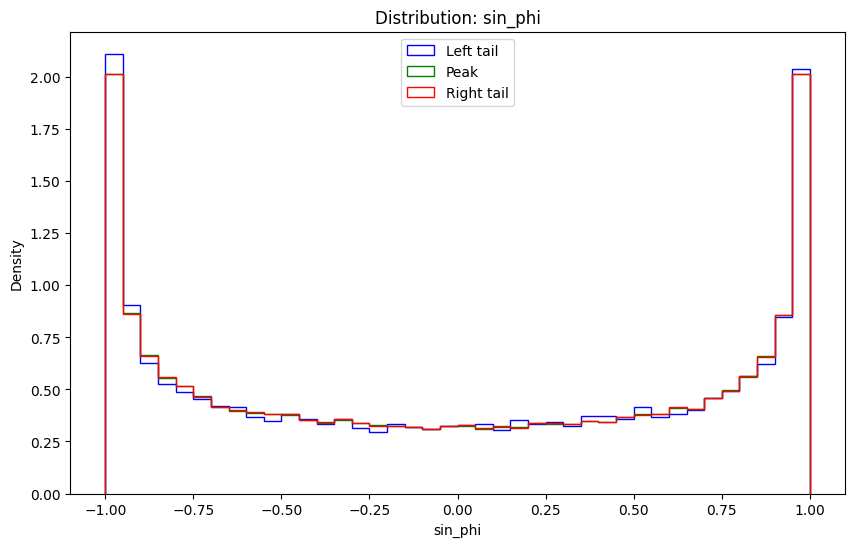

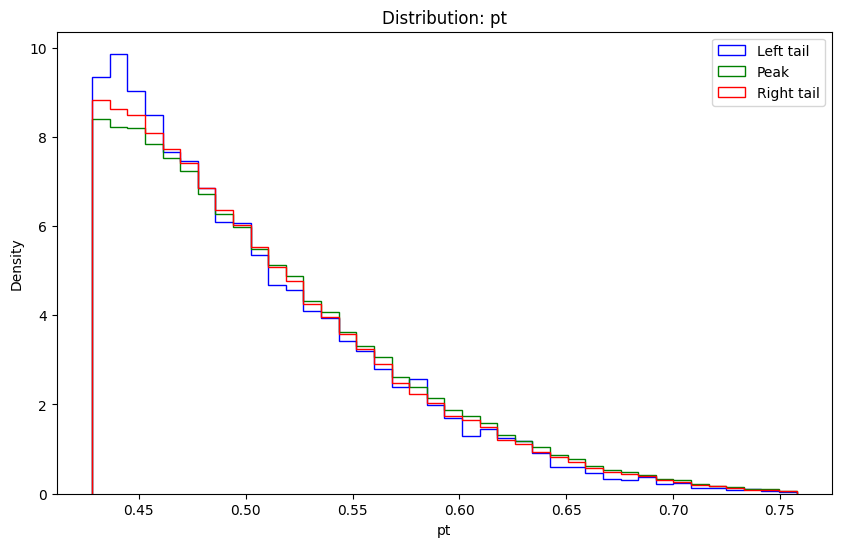

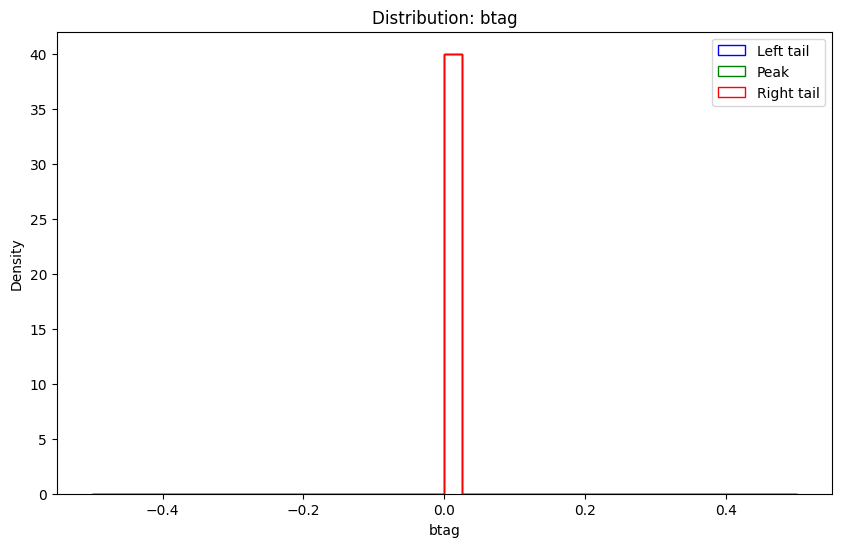

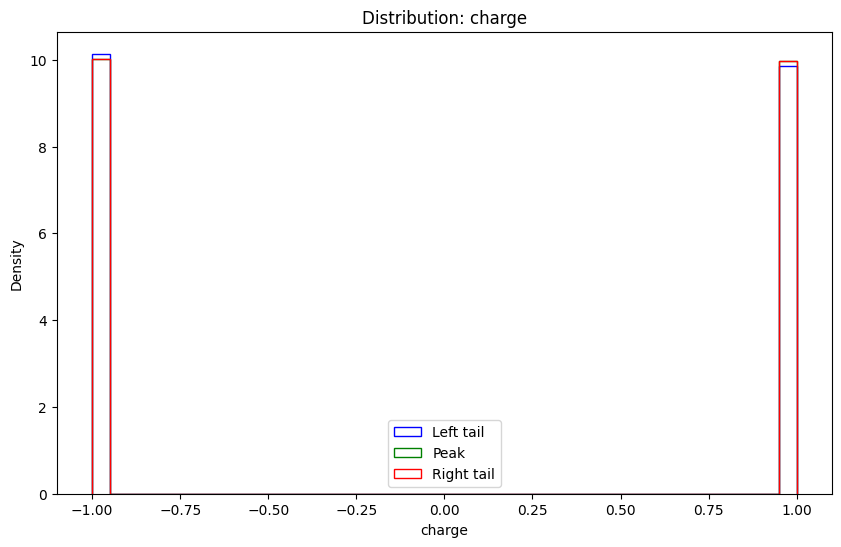

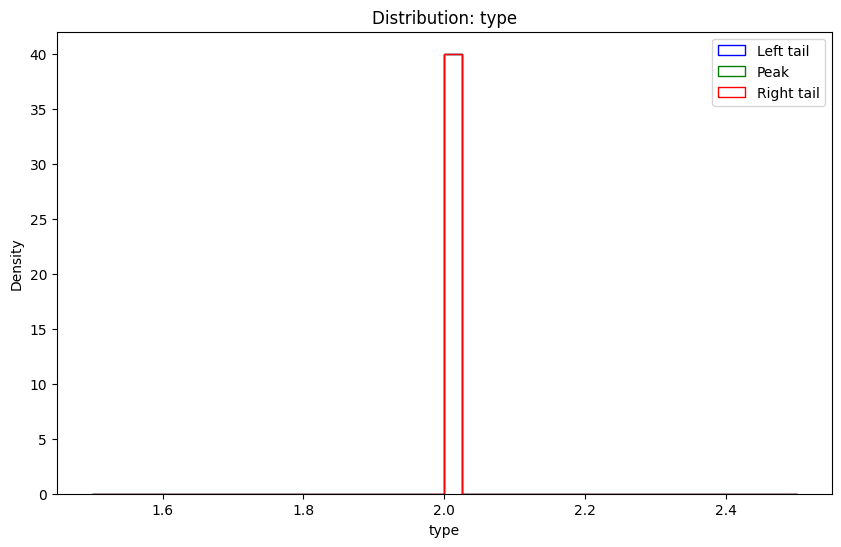

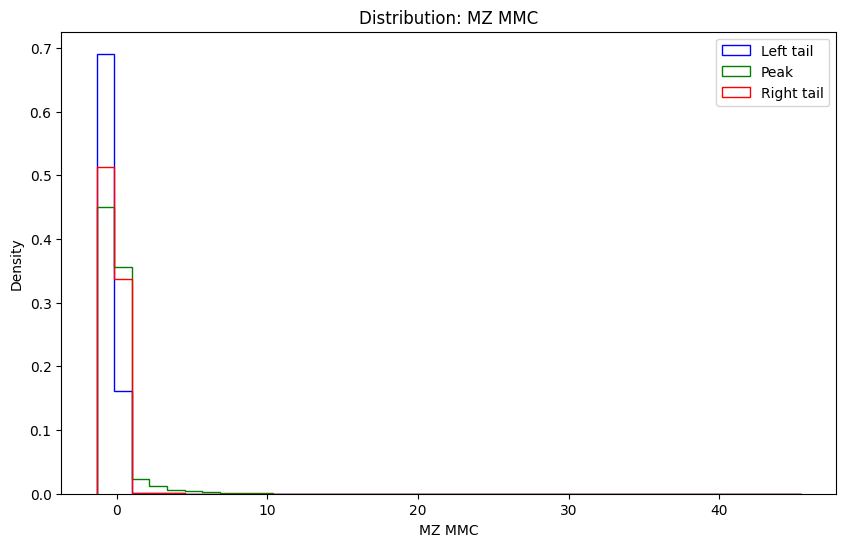

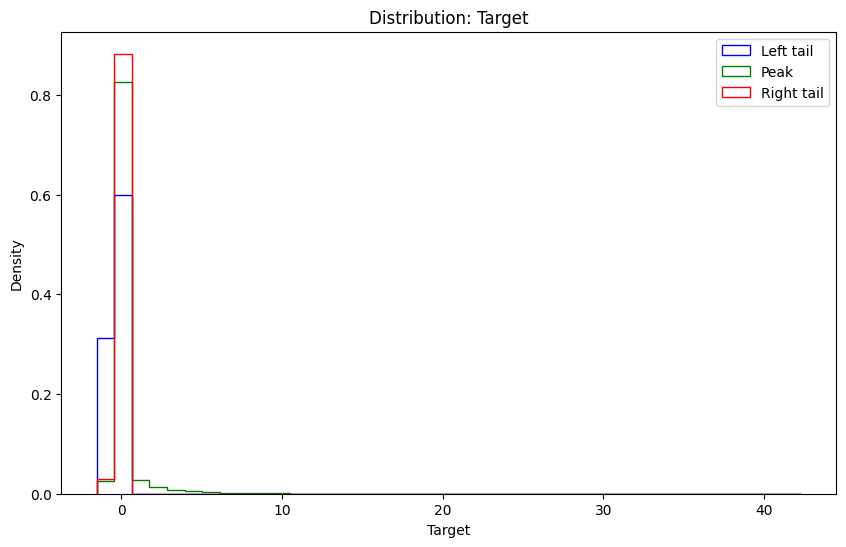

In [250]:
for ind, val in enumerate(['e', 'eta', 'cos_phi', 'sin_phi', 'pt', 'btag', 'charge', 'type']):
        compare_distribution_tails(X_train[:, ind*N_PARTICLES],left_tail_ind[idx_train],right_tail_ind[idx_train],variable_name=val, metadata=True)

for i in range(len(Extra_train[0])):
    compare_distribution_tails(Extra_train[:, i],left_tail_ind[idx_train],right_tail_ind[idx_train],variable_name='MZ MMC', metadata=True)

# Plot the scaled targets as well
compare_distribution_tails(y_train,left_tail_ind[idx_train],right_tail_ind[idx_train],variable_name='Target', metadata=True)

In [251]:
# For a transformer, 'tokens' are the inputs, in Natural Language Processing these would be part of words and punctuation. 
# Hence each particle will be its own token and in each of these the extra feature will be added at the end
# Despite against common sense of feeding the model tokens with one equal feature, this has shown to give the best results

X_train = X_train.reshape(X_train.shape[0], 5, 8)
X_val   = X_val.reshape(X_val.shape[0], 5, 8)
X_test  = X_test.reshape(X_test.shape[0], 5, 8)

X_train = X_train.transpose(0, 2, 1)
X_val = X_val.transpose(0, 2, 1)
X_test = X_test.transpose(0, 2, 1)

print(X_train.shape)

extra_train_repeated = np.repeat(Extra_train[:, :, np.newaxis], X_train.shape[2], axis=2)
X_train = np.concatenate([X_train, extra_train_repeated], axis=1)
extra_val_repeated = np.repeat(Extra_val[:, :, np.newaxis], X_val.shape[2], axis=2)
X_val = np.concatenate([X_val, extra_val_repeated], axis=1)
extra_test_repeated = np.repeat(Extra_test[:, :, np.newaxis], X_test.shape[2], axis=2)
X_test = np.concatenate([X_test, extra_test_repeated], axis=1)

print(X_train.shape)

# printing the first two tokens to check they both have the same final mz_mmc value
print(X_train[0, :, 0])
print(X_train[0, :, 1])

(155536, 8, 5)
(155536, 9, 5)
[ 0.46267241  0.44457698  0.30205491  0.64285725  0.5770067  -0.17183658
 -1.08039093  0.          0.08865391]
[-0.52322626  0.18078771 -0.10541645 -0.9230364  -0.23216152 -0.19441892
  0.68267232  0.99442816  0.08865391]


In [252]:
X_train_tensor = torch.nan_to_num(torch.tensor(X_train, dtype=torch.float32), nan=-1)
X_val_tensor   = torch.nan_to_num(torch.tensor(X_val, dtype=torch.float32), nan=-1)
X_test_tensor  = torch.nan_to_num(torch.tensor(X_test, dtype=torch.float32), nan=-1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_batch = 8192
eval_batch = 4092

train_loader = DataLoader(train_dataset, batch_size=train_batch,  shuffle=True, num_workers=15, persistent_workers= True, drop_last=True, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=eval_batch, shuffle=False, num_workers=15, persistent_workers= True, drop_last=True, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=eval_batch, shuffle=False, num_workers=15)

# The model

In [253]:
class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        # src: The input token embeddings
        # src2: The attention transformermed tokens
        
        # Call self-attention with need_weights=True
        src2, attn_weights = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False # To get the attention of each head
        )

        # drop out + residual connection + layer norm + linear feed forward with ReLU (inherited from base class)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src, attn_weights

class BasicTransformer(nn.Module):
    def __init__(self, input_dim, nhead=2, num_layers=2, dnn_layers=[32, 64], dropout=0.1):
        super(BasicTransformer, self).__init__()

        # === Input Embedder ===
        input_layers = []
        prev_dim = input_dim
        for dim in dnn_layers:
            input_layers.append(nn.Linear(prev_dim, dim))

            # Add normalization layer here if desired
            
            input_layers.append(nn.ReLU())

            # Add dropout if > 0
            if dropout > 0:
                input_layers.append(nn.Dropout(dropout))

            prev_dim = dim
            
        self.input_embedder = nn.Sequential(*input_layers)

        embed_dim = dnn_layers[-1]  # Last layer size

        # === Transformer === 
        # Stacks num_layers of the custom encoder layers 
        self.transformer_encoder = nn.ModuleList([
            CustomTransformerEncoderLayer(
                d_model=embed_dim,
                nhead=nhead,
                batch_first=True, 
                norm_first=True,
                dropout=dropout,
            ) for _ in range(num_layers)
        ])

        # === Output head ===
        self.output_linear = nn.Sequential(
            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def mean_pooling(self, x):
        return x.mean(dim=1)

    def forward(self, x, return_attentions=False):
        x = self.input_embedder(x)
        all_attentions = []
        
        for layer in self.transformer_encoder:
            x, attn = layer(x)
            all_attentions.append(attn)  # shape: [batch, seq, seq]

        x = self.mean_pooling(x)
        x = self.output_linear(x)

        # Using linear activation (return x) can be different if targets are scaled diff.

        if return_attentions:
            return x, all_attentions
        return x

In [254]:
input_dim = X_train.shape[2]
model = BasicTransformer(input_dim, nhead=8, num_layers=2, dnn_layers=[64, 128], dropout=0.15)
model = model.to(device)

LR = 0.00003
Weight_decay = 1e-3

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=Weight_decay)
criterion = nn.SmoothL1Loss(beta=2.0, reduction='mean')
# summary(model, input_size=(1, X_train.shape[1], X_train.shape[2]))

# Training the model

In [255]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_state = None

lr_scheduler_patience = 5
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=lr_scheduler_patience)

patience = 10      # how many epochs to wait before stopping after no improvement
epochs_no_improve = 0
num_epochs = 500

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        inputs_device = inputs.to(device, non_blocking=True)
        targets_device = targets.to(device, non_blocking=True)
        outputs = model(inputs_device)
        loss = criterion(outputs.squeeze(), targets_device)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs_device = inputs.to(device, non_blocking=True)
            targets_device = targets.to(device, non_blocking=True)
            outputs = model(inputs_device)
            loss = criterion(outputs.squeeze(), targets_device)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0  # reset counter
    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}", end='\r')

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs.")
        break

# Load best model weights before testing or saving
model.load_state_dict(best_model_state)

Epoch 114/500, Train Loss: 0.0359, Val Loss: 0.0375, LR: 0.000008
Early stopping triggered after 114 epochs.


<All keys matched successfully>

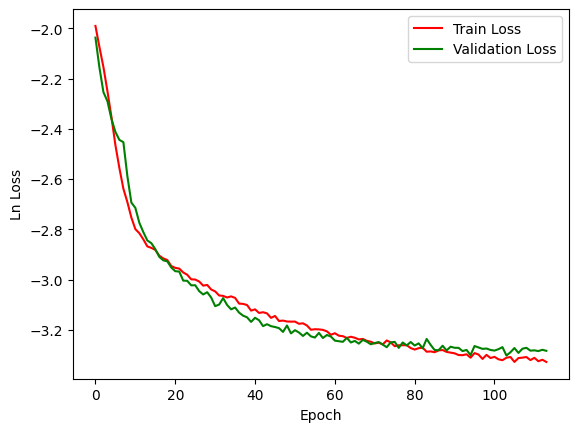

In [262]:
plt.plot(np.log(train_losses), label='ln Train Loss', color='red')
plt.plot(np.log(val_losses), label='ln Validation Loss', color='green')
plt.xlabel('Epoch')
plt.ylabel('Ln Loss')
plt.legend(['Train Loss', 'Validation Loss'])

# Save if model good

In [263]:
save_model = False
if save_model:
    torch.save(model.state_dict(), 'model_weights.pth')

# Evaluating Model Performance
Notably the attention head results can be obtained and can be explored to check what tokens the model attends to the most. They are purposefully left out in this notebook as they don't give many insights from the testing performed.

In [264]:
# Force everything on CPU
device = torch.device("cpu")
model = model.to(device)
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).squeeze().cpu().numpy() 
    y_true_test = y_test_tensor.cpu().numpy()
    y_pred_test = target_scaler.inverse_transform(y_pred_test.reshape(-1, 1)).flatten()
    y_true_test = target_scaler.inverse_transform(y_true_test.reshape(-1, 1)).flatten()


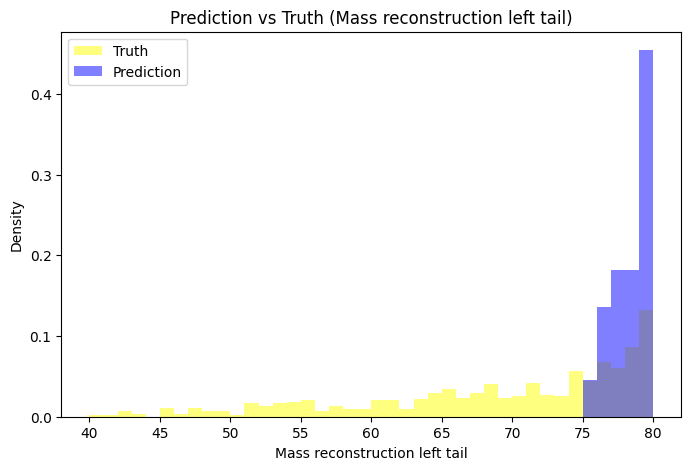

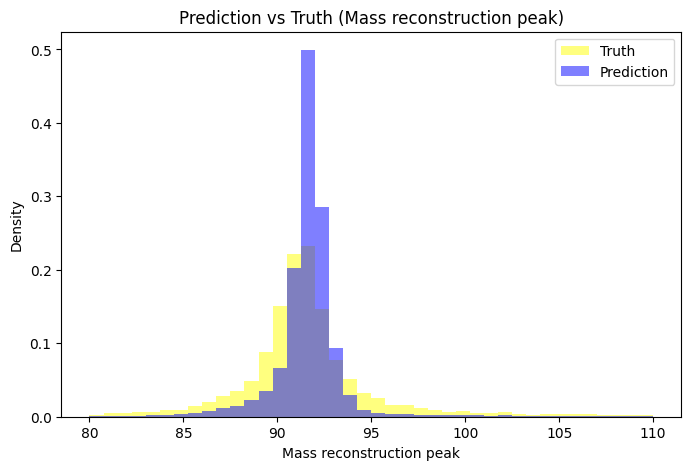

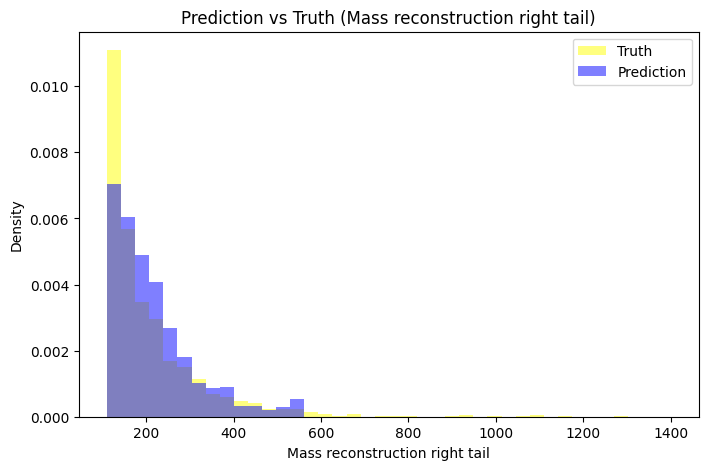

In [265]:
# Plotting prediction vs. truth
def plot_pred_truth(y_pred, y_true, x_range=None, n_bins=40, variable_name="Value"):
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)

    if x_range is None:
        x_range_min = min(np.nanmin(y_pred), np.nanmin(y_true))
        x_range_max = max(np.nanmax(y_pred), np.nanmax(y_true))
        x_range = [x_range_min, x_range_max]

    plt.figure(figsize=(8, 5), dpi=100)
    plt.hist(y_true, bins=n_bins, range=x_range, density=True, color='yellow', alpha=0.5, label='Truth')
    plt.hist(y_pred, bins=n_bins, range=x_range, density=True, color='blue', alpha=0.5, label='Prediction')
    plt.xlabel(variable_name)
    plt.ylabel('Density')
    plt.title(f'Prediction vs Truth ({variable_name})')
    plt.legend()
    plt.show() 
    
plot_pred_truth(y_pred_test, y_true_test, x_range=[40, 80], n_bins=40, variable_name="Mass reconstruction left tail")
plot_pred_truth(y_pred_test, y_true_test, x_range=[80, 110], n_bins=40, variable_name="Mass reconstruction peak")
plot_pred_truth(y_pred_test, y_true_test, x_range=[110, 1400], n_bins=40, variable_name="Mass reconstruction right tail")

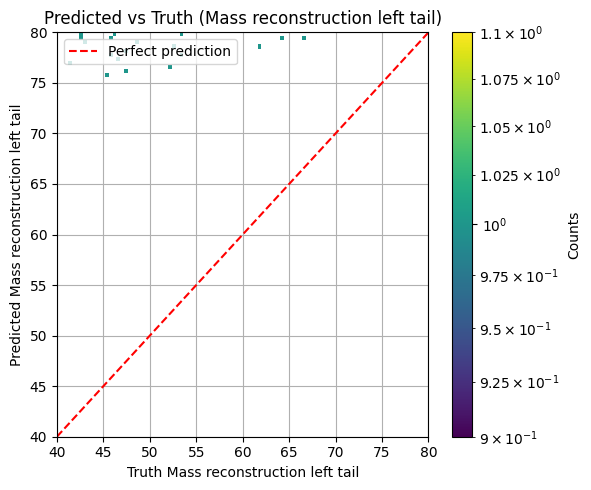

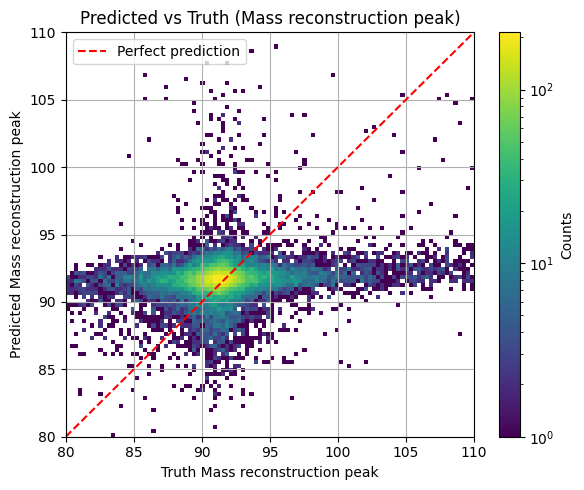

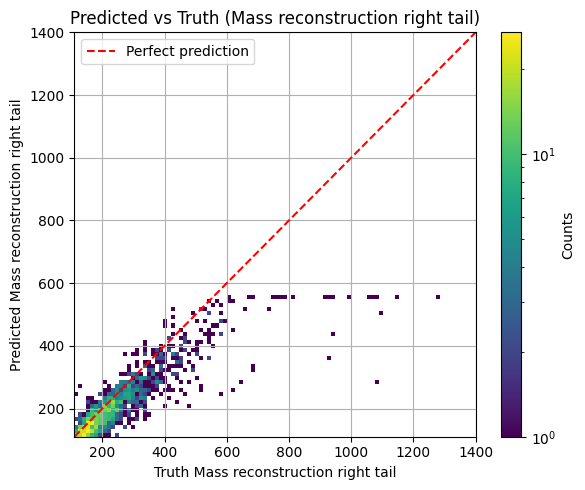

In [266]:
# 2-D Plots
def plot_pred_vs_truth_2d(y_pred, y_true, x_range=None, variable_name="Value", bins=100):
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)

    if x_range is None:
        min_val = min(np.nanmin(y_pred), np.nanmin(y_true))
        max_val = max(np.nanmax(y_pred), np.nanmax(y_true))
        x_range = [min_val, max_val]

    H, xedges, yedges = np.histogram2d(y_true, y_pred, bins=bins, range=[x_range, x_range])
    H_masked = np.ma.masked_where(H == 0, H) # Mask zeros so they appear as white

    # Create colormap with white for bad values
    cmap = plt.cm.viridis
    cmap.set_bad(color='white')

    plt.figure(figsize=(6, 5), dpi=100)
    mesh = plt.pcolormesh(xedges, yedges, H_masked.T, cmap=cmap, norm=mcolors.LogNorm(vmin=1, vmax=H.max()))
    plt.colorbar(mesh, label='Counts')

    plt.plot(x_range, x_range, 'r--', label='Perfect prediction') # Ideal prediction

    plt.xlabel(f"Truth {variable_name}")
    plt.ylabel(f"Predicted {variable_name}")
    plt.title(f"Predicted vs Truth ({variable_name})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pred_vs_truth_2d(y_pred_test, y_true_test, x_range=[40, 80], variable_name="Mass reconstruction left tail")
plot_pred_vs_truth_2d(y_pred_test, y_true_test, x_range=[80, 110], variable_name="Mass reconstruction peak")
plot_pred_vs_truth_2d(y_pred_test, y_true_test, x_range=[110, 1400], variable_name="Mass reconstruction right tail")

In [267]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_true_test, y_pred_test)
mae = mean_absolute_error(y_true_test, y_pred_test)
mse = mean_squared_error(y_true_test, y_pred_test)
frac_bias = np.mean((y_pred_test - y_true_test) / y_true_test)

print(f"{'R²':25s}: {r2:.4f}")
print(f"{'Mean Absolute Error':25s}: {mae:.4f}")
print(f"{'Mean Squared Error':25s}: {mse:.4f}")
print(f"{'Mean Fractional Bias':25s}: {frac_bias:.4%}")  # in %

R²                       : 0.7886
Mean Absolute Error      : 7.6052
Mean Squared Error       : 628.2780
Mean Fractional Bias     : -0.1617%
